<a href="https://colab.research.google.com/github/Nikikanaparthi21/data266-6441/blob/main/neural_networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Nikhil Kanaparthi
## DATA 266 - Homework 1

In [1]:
import os
import random
import numpy as np
import pandas as pd
import torch
import tensorflow as tf

SID4 = 6441
SEED = 6441
SLICE = 441
HP_ID = 3
CLS_A = 1
CLS_B = 7

def set_all_seeds(seed):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    tf.keras.utils.set_random_seed(seed)

set_all_seeds(SEED)

print("SID4:", SID4)
print("SEED:", SEED)
print("SLICE:", SLICE)
print("HP_ID:", HP_ID)
print("CLS_A:", CLS_A)
print("CLS_B:", CLS_B)

SID4: 6441
SEED: 6441
SLICE: 441
HP_ID: 3
CLS_A: 1
CLS_B: 7


## 1. Diabetes Dataset

### 1.1 Load and verify the dataset

The supplied CSV has no header row. Descriptive column names are assigned
when the file is loaded.

In [2]:
FEATURE_NAMES = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]

COLUMN_NAMES = FEATURE_NAMES + ["Outcome"]

df = pd.read_csv(
    "diabetes.csv",
    header=None,
    names=COLUMN_NAMES
)

display(df.head())

print("Dataset shape:", df.shape)
print("\nMissing values:", df.isna().sum().sum())
print("\nClass counts:")
print(df["Outcome"].value_counts().sort_index())

assert df.shape == (759, 9), "Unexpected dataset shape"
assert df.isna().sum().sum() == 0, "Dataset contains missing values"
assert set(df["Outcome"].unique()) == {0, 1}, "Outcome is not binary"

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,-0.294118,0.487437,0.180328,-0.292929,0.000000,0.001490,-0.531170,-0.033333,0
1,-0.882353,-0.145729,0.081967,-0.414141,0.000000,-0.207153,-0.766866,-0.666667,1
2,-0.058824,0.839196,0.049180,0.000000,0.000000,-0.305514,-0.492741,-0.633333,0
3,-0.882353,-0.105528,0.081967,-0.535354,-0.777778,-0.162444,-0.923997,0.000000,1
4,0.000000,0.376884,-0.344262,-0.292929,-0.602837,0.284650,0.887276,-0.600000,0


Dataset shape: (759, 9)

Missing values: 0

Class counts:
Outcome
0    263
1    496
Name: count, dtype: int64


## 2. Diabetes Dataset: Neural-Network Implementation

### 2.1 Load and verify the data

The supplied diabetes CSV contains eight normalized numerical features and
one binary target. The file has no header row, so descriptive column names
are assigned while loading it.

In [3]:
FEATURE_NAMES = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]

COLUMN_NAMES = FEATURE_NAMES + ["Outcome"]

df = pd.read_csv(
    "diabetes.csv",
    header=None,
    names=COLUMN_NAMES
)

display(df.head())

print("Dataset shape:", df.shape)
print("Missing values:", df.isna().sum().sum())

print("\nClass counts:")
print(df["Outcome"].value_counts().sort_index())

assert df.shape == (759, 9), "The dataset was not loaded correctly."
assert df.isna().sum().sum() == 0, "Unexpected missing values found."
assert set(df["Outcome"].unique()) == {0, 1}, "Outcome must be binary."

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,-0.294118,0.487437,0.180328,-0.292929,0.000000,0.001490,-0.531170,-0.033333,0
1,-0.882353,-0.145729,0.081967,-0.414141,0.000000,-0.207153,-0.766866,-0.666667,1
2,-0.058824,0.839196,0.049180,0.000000,0.000000,-0.305514,-0.492741,-0.633333,0
3,-0.882353,-0.105528,0.081967,-0.535354,-0.777778,-0.162444,-0.923997,0.000000,1
4,0.000000,0.376884,-0.344262,-0.292929,-0.602837,0.284650,0.887276,-0.600000,0


Dataset shape: (759, 9)
Missing values: 0

Class counts:
Outcome
0    263
1    496
Name: count, dtype: int64


### 2.2 Preprocessing checks

The feature ranges are inspected before modeling. Because the supplied
features are already normalized and contain no missing values, no additional
imputation or scaling is applied.

In [4]:
feature_ranges = df[FEATURE_NAMES].agg(["min", "max"]).T
display(feature_ranges)

,min,max
Pregnancies,-0.882353,1.0
Glucose,-0.557789,1.0
BloodPressure,-0.606557,1.0
SkinThickness,-0.858586,1.0
Insulin,-0.966903,1.0
BMI,-0.457526,1.0
DiabetesPedigreeFunction,-0.994876,1.0
Age,-0.966667,1.0


### 2.3 Correlation matrix

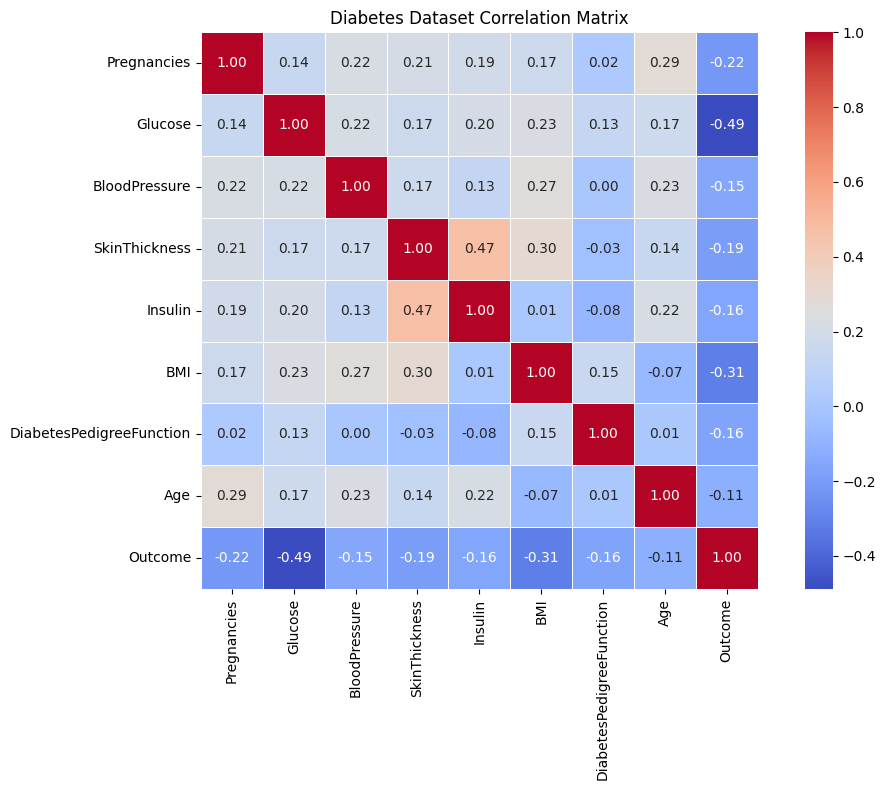

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(11, 8))

sns.heatmap(
    df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.5
)

plt.title("Diabetes Dataset Correlation Matrix")
plt.tight_layout()
plt.show()

### 2.4 Feature distributions

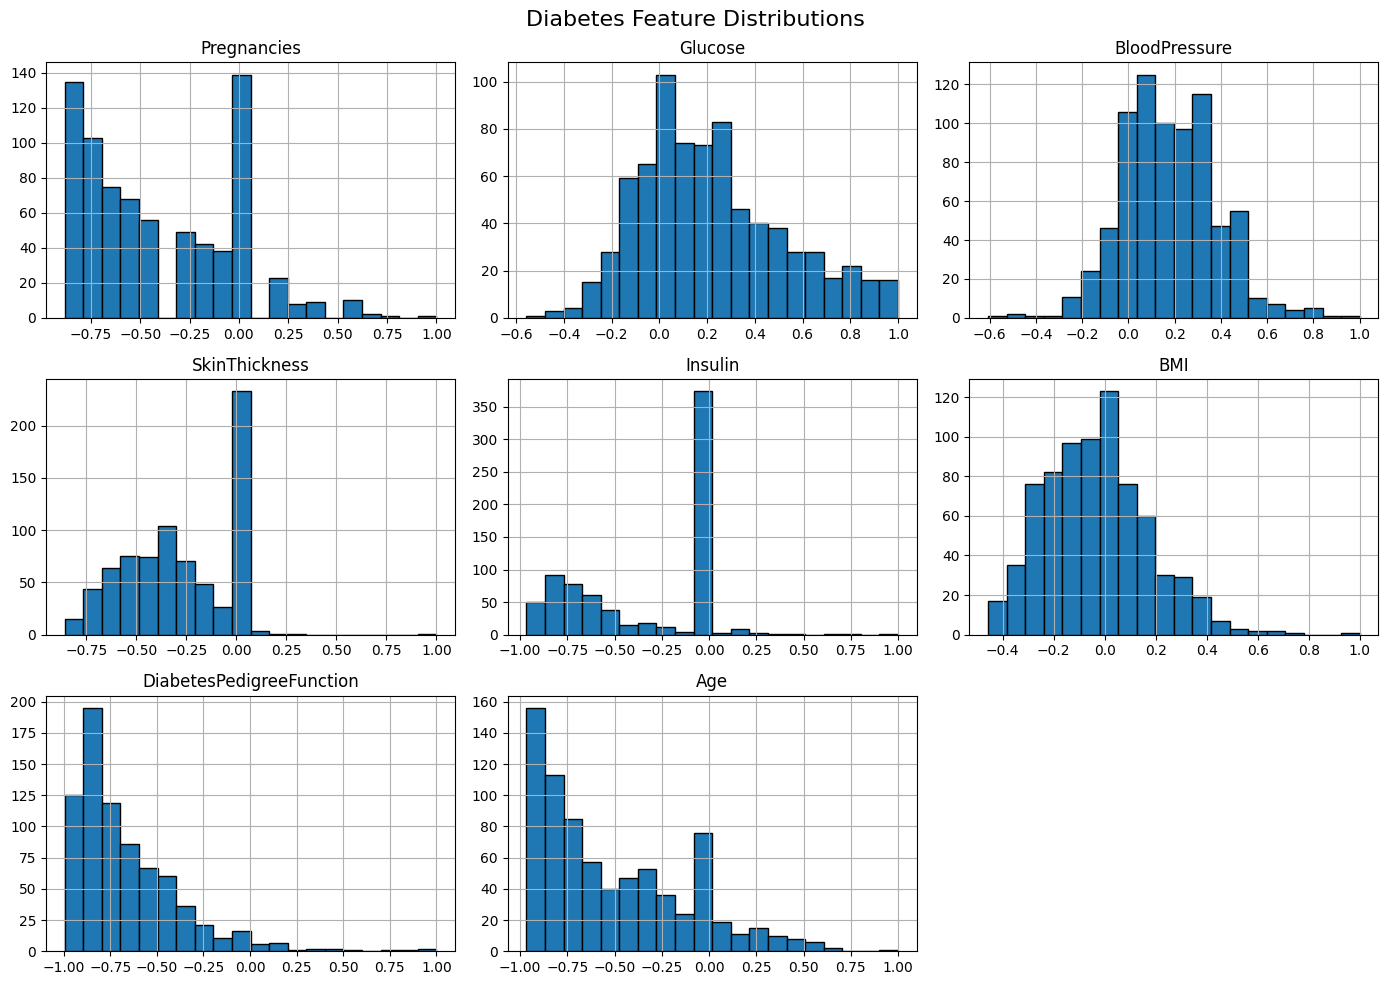

In [6]:
axes = df[FEATURE_NAMES].hist(
    figsize=(14, 10),
    bins=20,
    edgecolor="black"
)

plt.suptitle("Diabetes Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()

### 2.5 Fixed training, validation, and testing split

The dataset is divided into 70% training, 15% validation, and 15% testing
subsets. The split uses `random_state=SEED` and stratification so that class
proportions remain similar across all subsets. This exact split will be used
for every PyTorch and TensorFlow experiment.

In [7]:
from sklearn.model_selection import train_test_split

X = df[FEATURE_NAMES].to_numpy(dtype=np.float32)
y = df["Outcome"].to_numpy(dtype=np.float32)

# First split: 70% training and 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

# Second split: divide temporary data equally into validation and testing
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print("Training shapes:  ", X_train.shape, y_train.shape)
print("Validation shapes:", X_val.shape, y_val.shape)
print("Testing shapes:   ", X_test.shape, y_test.shape)

print("\nTraining positive rate:  ", y_train.mean())
print("Validation positive rate:", y_val.mean())
print("Testing positive rate:   ", y_test.mean())

assert X_train.shape == (531, 8)
assert X_val.shape == (114, 8)
assert X_test.shape == (114, 8)

Training shapes:   (531, 8) (531,)
Validation shapes: (114, 8) (114,)
Testing shapes:    (114, 8) (114,)

Training positive rate:   0.653484
Validation positive rate: 0.64912283
Testing positive rate:    0.65789473
